#  Notebook 3 — Model Evaluation
**Steps covered:**
1. Load saved model
2. Run inference on test set
3. Compute TP / FP / FN per class
4. Precision, Recall, F1 table
5. Per-class bar chart (GT vs Predicted counts)
6. Confusion matrix (seaborn heatmap)
7. Loss curves from TensorBoard CSV export

**Input:** Saved model from Notebook 2, `annotations.json` files

---

In [ ]:
# ============================================================
#  CONFIG
# ============================================================
import os

DATASET_BASE    = "dataset"      #  root dataset folder
MODEL_LOAD_PATH = "saved_model"  #  path to saved model (from Notebook 2)
LOSS_CSV_PATH   = "loss.csv"     #  TensorBoard CSV export (optional)

IMAGE_SIZE          = 480   #  must match training image size
CONFIDENCE_THRESHOLD = 0.5  #  detection confidence threshold
IOU_THRESHOLD        = 0.5  #  IoU threshold for TP/FP classification
NMS_THRESHOLD        = 0.75 #  NMS threshold to suppress duplicate boxes
EVAL_SUBSET_SIZE     = 500  #  how many test images to evaluate on
BATCH_SIZE           = 2    #  inference batch size

CLASSES = [
    "traffic light", "traffic sign", "car", "person", "bus",
    "truck", "rider", "bike", "motor", "train", "banner", "tuktuk"
]

SPLITS = {
    "train": os.path.join(DATASET_BASE, "train", "train"),
    "val"  : os.path.join(DATASET_BASE, "val",   "val"),
    "test" : os.path.join(DATASET_BASE, "test",  "test"),
}

print(" Config loaded!")

✅ Config loaded!


## Step 1 — Load Saved Model

In [ ]:
import torch, warnings
import torchvision
from transformers import DetrForObjectDetection, DetrImageProcessor
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

image_processor = DetrImageProcessor.from_pretrained(MODEL_LOAD_PATH)
model = DetrForObjectDetection.from_pretrained(MODEL_LOAD_PATH)
model.to(DEVICE)
model.eval()

id2label = {i: name for i, name in enumerate(CLASSES)}

print(f"   Model loaded from: {MODEL_LOAD_PATH}")
print(f"   Device: {DEVICE}")

Loading weights: 100%|██████████| 530/530 [00:00<00:00, 4999.99it/s]


✅ Model loaded from: saved_model
   Device: cuda


## Step 2 — Load Test Dataset

In [ ]:
import os, torchvision
from torch.utils.data import DataLoader

class CocoDetection(torchvision.datasets.CocoDetection):
    def __init__(self, split_path, image_processor, train=False):
        ann_file     = os.path.join(split_path, "annotations.json")
        image_folder = os.path.join(split_path, "images")
        super().__init__(image_folder, ann_file)
        self.image_processor = image_processor

    def __getitem__(self, idx):
        images, annotations = super().__getitem__(idx)
        image_id  = self.ids[idx]
        annotations = {"image_id": image_id, "annotations": annotations}
        encoding  = self.image_processor(images=images, annotations=annotations, return_tensors="pt")
        return encoding["pixel_values"].squeeze(), encoding["labels"][0]

TEST_DATASET  = CocoDetection(SPLITS["test"],  image_processor)
TRAIN_DATASET = CocoDetection(SPLITS["train"], image_processor, train=True)
VAL_DATASET   = CocoDetection(SPLITS["val"],   image_processor)

print(f" Test dataset: {len(TEST_DATASET)} images")

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
loading annotations into memory...
Done (t=0.89s)
creating index...
index created!
loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
✅ Test dataset: 5805 images


## Step 3 — Run Inference & Collect TP / FP / FN

In [ ]:
import torch, cv2, os
import numpy as np
from tqdm import tqdm
from collections import defaultdict, Counter
from torchvision.ops import nms

def compute_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""
    xA = max(box1[0], box2[0]); yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2]); yB = min(box1[3], box2[3])
    inter = max(0, xB-xA+1) * max(0, yB-yA+1)
    a1 = (box1[2]-box1[0]+1) * (box1[3]-box1[1]+1)
    a2 = (box2[2]-box2[0]+1) * (box2[3]-box2[1]+1)
    return inter / float(a1 + a2 - inter + 1e-6)

def convert_to_xywh(boxes):
    """Convert [x1,y1,x2,y2] → [x1,y1,w,h] for COCO eval format"""
    xmin, ymin, xmax, ymax = boxes.unbind(1)
    return torch.stack((xmin, ymin, xmax - xmin, ymax - ymin), dim=1)

def prepare_for_coco_detection(predictions):
    """Convert predictions dict to COCO results format."""
    coco_results = []
    for original_id, prediction in predictions.items():
        if len(prediction) == 0: continue
        boxes  = convert_to_xywh(prediction["boxes"]).tolist()
        scores = prediction["scores"].tolist()
        labels = prediction["labels"].tolist()
        coco_results.extend([
            {"image_id": original_id, "category_id": labels[k], "bbox": box, "score": scores[k]}
            for k, box in enumerate(boxes)
        ])
    return coco_results

# Evaluation loop
true_positives  = defaultdict(int)
false_positives = defaultdict(int)
false_negatives = defaultdict(int)
predictions_coco_format = []
gt_counts   = Counter()
pred_counts = Counter()

eval_ids = TEST_DATASET.ids[:EVAL_SUBSET_SIZE]

for img_id in tqdm(eval_ids, desc="Evaluating"):
    img_info = TEST_DATASET.coco.loadImgs(img_id)[0]
    img_path = os.path.join(TEST_DATASET.root, img_info["file_name"])
    image    = cv2.imread(img_path)
    if image is None: continue
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    inputs = image_processor(images=image_rgb, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)

    results = image_processor.post_process_object_detection(
        outputs, threshold=CONFIDENCE_THRESHOLD,
        target_sizes=torch.tensor([[h, w]]).to(DEVICE)
    )[0]

    # Apply NMS
    if len(results["boxes"]) > 0:
        keep = nms(results["boxes"], results["scores"], NMS_THRESHOLD)
        pred_boxes  = results["boxes"][keep].cpu()
        pred_labels = results["labels"][keep].cpu()
        pred_scores = results["scores"][keep].cpu()
    else:
        pred_boxes = pred_labels = pred_scores = torch.tensor([])

    # Store COCO format predictions
    if len(pred_boxes) > 0:
        predictions_coco_format.extend([
            {"image_id": img_id, "category_id": pred_labels[k].item(),
             "bbox": convert_to_xywh(pred_boxes[k:k+1]).squeeze().tolist(),
             "score": pred_scores[k].item()}
            for k in range(len(pred_boxes))
        ])

    # GT annotations
    gt_anns   = TEST_DATASET.coco.loadAnns(TEST_DATASET.coco.getAnnIds(imgIds=img_id))
    gt_boxes  = [[a["bbox"][0], a["bbox"][1], a["bbox"][0]+a["bbox"][2], a["bbox"][1]+a["bbox"][3]] for a in gt_anns]
    gt_labels = [a["category_id"] for a in gt_anns]

    for gl in gt_labels: gt_counts[gl] += 1
    for pl in pred_labels.tolist(): pred_counts[int(pl)-1] += 1

    matched_gt = set()
    for pb, pl in zip(pred_boxes.tolist(), pred_labels.tolist()):
        cls_id   = int(pl) - 1
        best_iou, best_j = 0, -1
        for j, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
            if gl == cls_id and j not in matched_gt:
                v = compute_iou(pb, gb)
                if v > best_iou: best_iou, best_j = v, j
        if best_iou >= IOU_THRESHOLD and best_j >= 0:
            true_positives[cls_id]  += 1
            matched_gt.add(best_j)
        else:
            false_positives[cls_id] += 1

    for j, gl in enumerate(gt_labels):
        if j not in matched_gt:
            false_negatives[gl] += 1

print(f"\n Evaluation complete on {len(eval_ids)} images")

Evaluating: 100%|██████████| 500/500 [00:27<00:00, 18.10it/s]


✅ Evaluation complete on 500 images


## Step 4 — Precision / Recall / F1 Table

In [14]:
import numpy as np

tp = true_positives; fp = false_positives; fn = false_negatives

print(f"\n{'Class':<15} {'TP':>6} {'FP':>6} {'FN':>6} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 62)

precisions, recalls, f1s = [], [], []
for i, cls in enumerate(CLASSES):
    p  = tp[i] / (tp[i] + fp[i] + 1e-6)
    r  = tp[i] / (tp[i] + fn[i] + 1e-6)
    f1 = 2 * p * r / (p + r + 1e-6)
    precisions.append(p); recalls.append(r); f1s.append(f1)
    print(f"{cls:<15} {tp[i]:>6} {fp[i]:>6} {fn[i]:>6} {p:>10.3f} {r:>8.3f} {f1:>8.3f}")

print("-" * 62)
print(f"{'MEAN':<15} {'':>6} {'':>6} {'':>6} {np.mean(precisions):>10.3f} {np.mean(recalls):>8.3f} {np.mean(f1s):>8.3f}")


Class               TP     FP     FN  Precision   Recall       F1
--------------------------------------------------------------
traffic light        5     82    160      0.057    0.030    0.040
traffic sign         2   2565    293      0.001    0.007    0.001
car                  1    632   1776      0.002    0.001    0.001
person               0      4    493      0.000    0.000    0.000
bus                 10     94    224      0.096    0.043    0.059
truck                0     49    311      0.000    0.000    0.000
rider                4    118     57      0.033    0.066    0.044
bike                 5     27    110      0.156    0.043    0.068
motor                0    204     24      0.000    0.000    0.000
train                0     17     70      0.000    0.000    0.000
banner               0      2      0      0.000    0.000    0.000
tuktuk               0      0      0      0.000    0.000    0.000
--------------------------------------------------------------
MEAN           

## Step 5 — GT vs Predicted Count Bar Chart

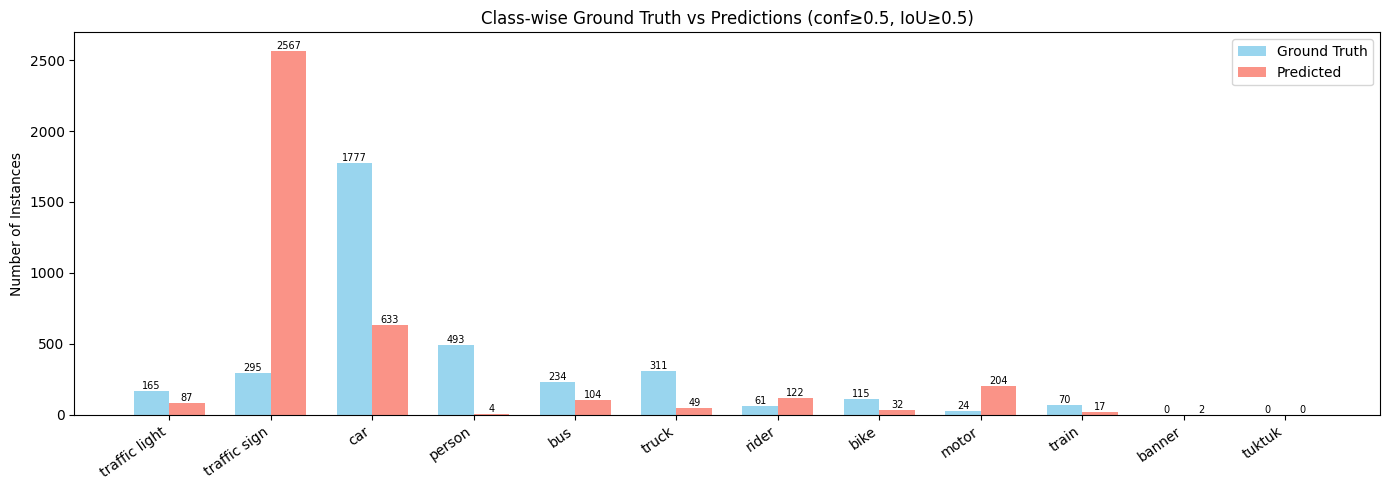

✅ Saved: gt_vs_pred_counts.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

all_class_ids = list(range(len(CLASSES)))
gt_vals   = [gt_counts.get(i, 0)   for i in all_class_ids]
pred_vals = [pred_counts.get(i, 0) for i in all_class_ids]

x = np.arange(len(CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars_gt   = ax.bar(x - width/2, gt_vals,   width, label='Ground Truth', color='skyblue',  alpha=0.85)
bars_pred = ax.bar(x + width/2, pred_vals, width, label='Predicted',    color='salmon',   alpha=0.85)
ax.bar_label(bars_gt,   fmt='%d', fontsize=7)
ax.bar_label(bars_pred, fmt='%d', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=10)
ax.set_ylabel("Number of Instances")
ax.set_title(f"Class-wise Ground Truth vs Predictions (conf≥{CONFIDENCE_THRESHOLD}, IoU≥{IOU_THRESHOLD})")
ax.legend()
plt.tight_layout()
# plt.savefig("gt_vs_pred_counts.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Precision & Recall Bar Chart

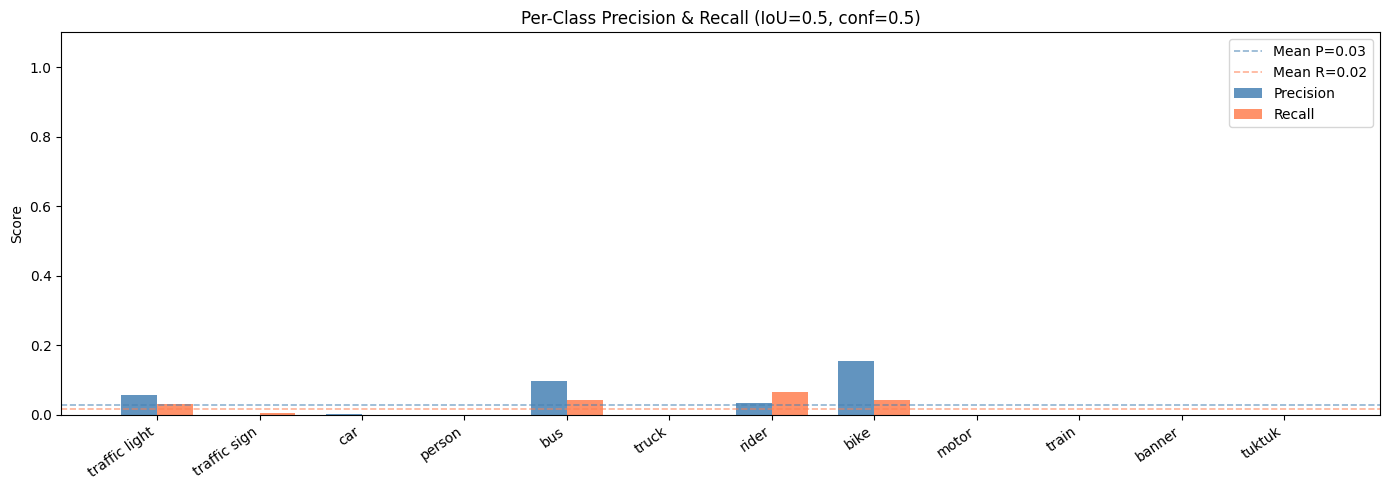

✅ Saved: precision_recall.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, precisions, width, label='Precision', color='steelblue', alpha=0.85)
ax.bar(x + width/2, recalls,    width, label='Recall',    color='coral',     alpha=0.85)
ax.axhline(np.mean(precisions), color='steelblue', linestyle='--', linewidth=1.2, alpha=0.6, label=f'Mean P={np.mean(precisions):.2f}')
ax.axhline(np.mean(recalls),    color='coral',     linestyle='--', linewidth=1.2, alpha=0.6, label=f'Mean R={np.mean(recalls):.2f}')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=35, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title(f"Per-Class Precision & Recall (IoU={IOU_THRESHOLD}, conf={CONFIDENCE_THRESHOLD})")
ax.legend()
plt.tight_layout()
# plt.savefig("precision_recall.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: precision_recall.png")

## Step 7 — Confusion Matrix

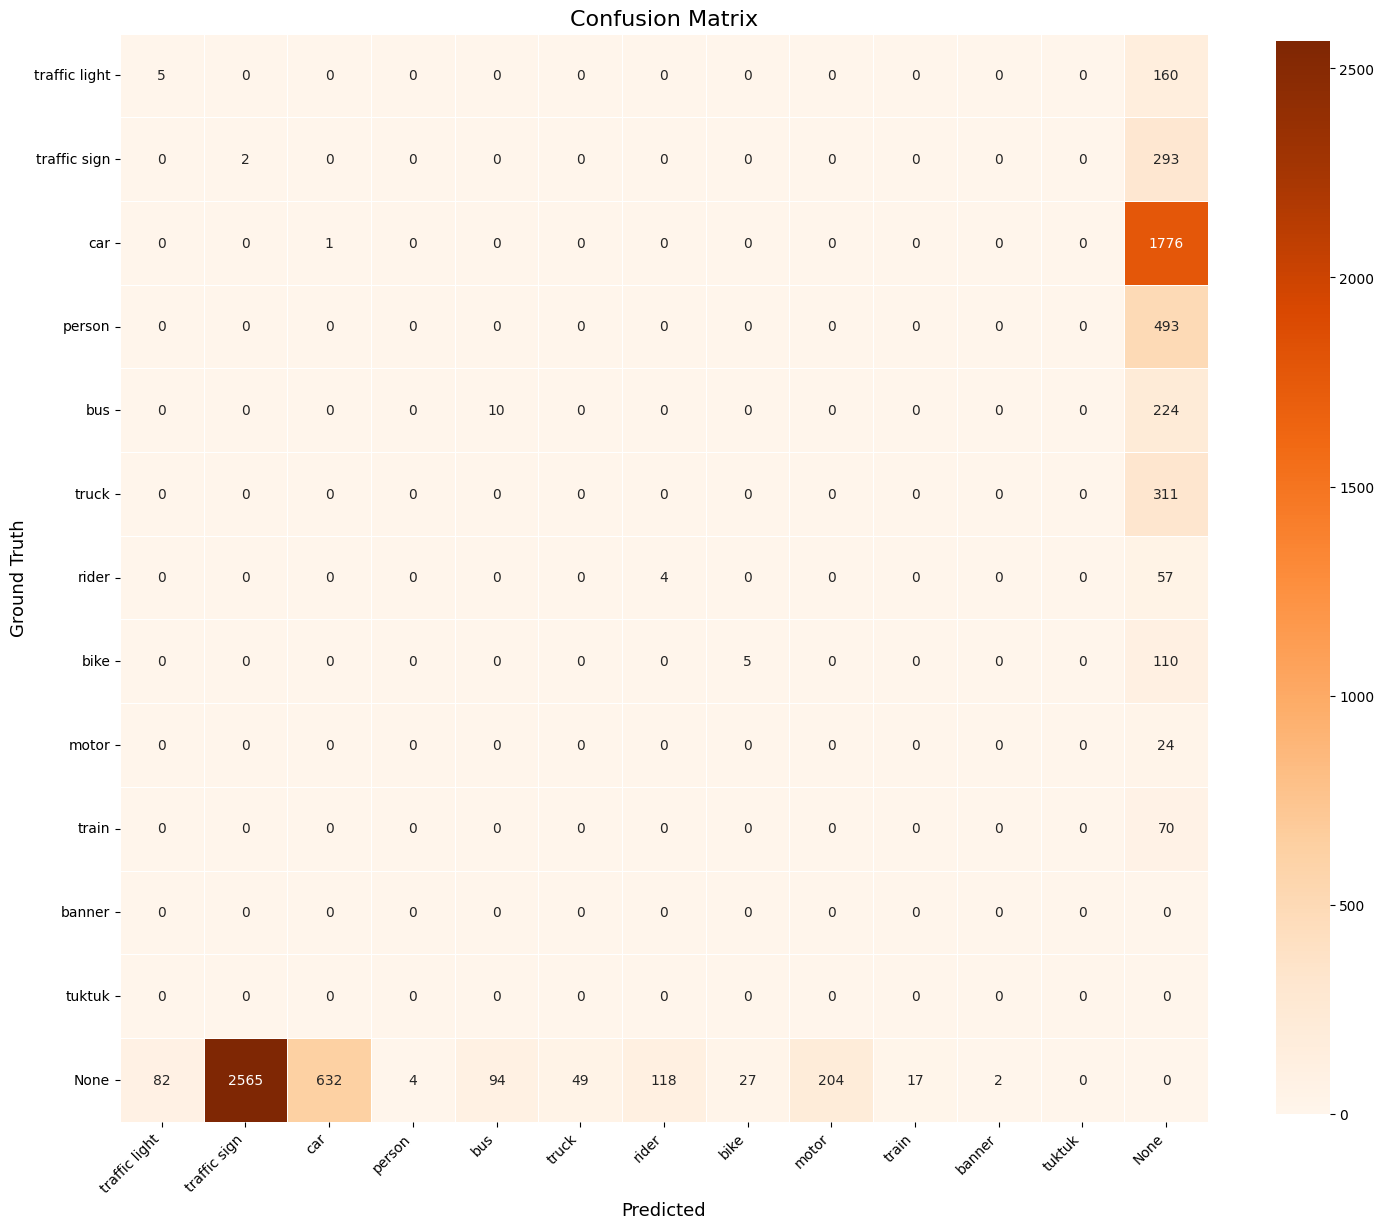

✅ Saved: confusion_matrix.png


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Build y_true and y_pred from TP/FP/FN
y_true, y_pred = [], []
for i, cls in enumerate(CLASSES):
    # True positives: predicted correctly
    y_true += [cls] * tp[i]
    y_pred += [cls] * tp[i]
    # False negatives: GT existed but not predicted
    y_true += [cls]   * fn[i]
    y_pred += ["None"] * fn[i]
    # False positives: predicted but no GT
    y_true += ["None"] * fp[i]
    y_pred += [cls]    * fp[i]

cm_labels = CLASSES + ["None"]
cm = confusion_matrix(y_true, y_pred, labels=cm_labels)

fig, ax = plt.subplots(figsize=(len(cm_labels)+2, len(cm_labels)+2))
sns.heatmap(
    cm, annot=True, fmt='d', cmap="Oranges",
    xticklabels=cm_labels, yticklabels=cm_labels,
    cbar=True, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.73}, annot_kws={"size": 10}, ax=ax
)
ax.set_title("Confusion Matrix", fontsize=16)
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("Ground Truth", fontsize=13)
ax.set_xticklabels(cm_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(cm_labels, rotation=0,  fontsize=10)
plt.tight_layout()
# plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Loss Curves from CSV
> Export metrics from TensorBoard: open TensorBoard → download CSV → set `LOSS_CSV_PATH`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

if not os.path.exists(LOSS_CSV_PATH):
    print(f"CSV not found at '{LOSS_CSV_PATH}'.")
else:
    df = pd.read_csv(LOSS_CSV_PATH)
    print("Available columns:", df.columns.tolist())

    def find_col(cols, keyword):
        return next((c for c in cols if keyword.lower() in c.lower()), None)

    epochs     = df.get("Epoch") or df.get("epoch") or df.index
    val_ce     = find_col(df.columns, 'val_loss_ce')
    val_giou   = find_col(df.columns, 'val_loss_giou')
    val_bbox   = find_col(df.columns, 'val_loss_bbox')
    val_total  = find_col(df.columns, 'val_loss')
    train_ce   = find_col(df.columns, 'train_loss_ce')
    train_giou = find_col(df.columns, 'train_loss_giou')
    train_bbox = find_col(df.columns, 'train_loss_bbox')
    train_total= find_col(df.columns, 'train_loss')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.set_title("Validation Losses per Epoch"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    if val_total: ax.plot(epochs, df[val_total],  label="Val Total",  linewidth=2)
    if val_ce:    ax.plot(epochs, df[val_ce],     label="Val CE",     linewidth=2)
    if val_giou:  ax.plot(epochs, df[val_giou],   label="Val GIoU",   linewidth=2)
    if val_bbox:  ax.plot(epochs, df[val_bbox],   label="Val BBox",   linewidth=2)
    ax.legend(); ax.grid(True)

    ax = axes[1]
    ax.set_title("Training Losses per Epoch"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    if train_total: ax.plot(epochs, df[train_total], label="Train Total", linestyle='--', linewidth=2)
    if train_ce:    ax.plot(epochs, df[train_ce],    label="Train CE",    linestyle='--', linewidth=2)
    if train_giou:  ax.plot(epochs, df[train_giou],  label="Train GIoU",  linestyle='--', linewidth=2)
    if train_bbox:  ax.plot(epochs, df[train_bbox],  label="Train BBox",  linestyle='--', linewidth=2)
    ax.legend(); ax.grid(True)

    plt.suptitle("Training & Validation Loss Curves", fontsize=14)
    plt.tight_layout()
    # plt.savefig("loss_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(" Saved: loss_curves.png")

⚠️  CSV not found at 'loss.csv'.
   To export: open TensorBoard → select metric → click Download CSV
   Then set LOSS_CSV_PATH = 'your_file.csv' in the config cell.
